In [1]:
import pandas as pd
import ehrapy as ep
import numpy as np
import os
from matplotlib import pyplot as plt
os.environ["NUMBA_WARNINGS"] = "1"

In [2]:
fname='../data/data_lab_meas_days_only_with_selected_cols.csv'
fname='tb22_1162_pats_34_vars' +'_preproc_data'
fname='tb20_21_2852_pats_27_vars' +'_preproc_data' 
#fname='pat_graph_390_pats_53_vars_preproc_data'

fn=os.path.join('../data',fname) +'.csv'

## Select columns to load
data_for_cols=pd.read_csv(fn, index_col=0, nrows=0)
obs_cols=data_for_cols.columns[data_for_cols.columns.str.startswith(('ae','cmday','mh','cmind','cmdos','index','out'))].tolist()
obs_cols=['STUDYID','USUBJID','ARM','DAY','SEX'] + obs_cols
adata = ep.io.read_csv(fn,index_column=0,columns_obs_only=obs_cols)

2023-06-01 13:23:12,172 - root INFO - Transformed passed dataframe into an AnnData object with n_obs x n_vars = `22482` x `40`.


In [3]:
bdata=adata.copy()

# Convert Unnamed to Index in var_names
#bdata.var_names = bdata.var_names.to_series().replace({'Unnamed: 0': 'Index'}).tolist()
print('var shape',bdata.var_names.shape)
print('obs shape',bdata.obs.shape)
print('X shape',bdata.X.shape)

var shape (40,)
obs shape (22482, 2767)
X shape (22482, 40)


In [4]:
print(bdata.uns['non_numerical_columns'])

## One-hot encode non-numerical columns
cdata=ep.pp.encode(bdata,encodings='one_hot_encoding',autodetect=True)
print(cdata.shape)


# Extract column names with more than 2 unique values and scale numerical columns
numerical_non_binary_cols = [col_name for col_name in cdata.var_names if len(np.unique(cdata[:, col_name].X)) > 2]
cdata_norm = ep.pp.scale_norm(cdata,copy=True,vars=numerical_non_binary_cols)


[]


Detected no columns that need to be encoded. Leaving passed AnnData object unchanged.

(22482, 40)
2023-06-01 13:23:17,294 - root INFO - Column names for numeric variables ['AGE', 'vs_Weight_STD_NUM_RESULT_SCALED', 'vs_Temperature_STD_NUM_RESULT_SCALED', 'vs_Diastolic Blood Pressure_STD_NUM_RESULT_SCALED', 'vs_Systolic Blood Pressure_STD_NUM_RESULT_SCALED', 'vs_Height_STD_NUM_RESULT_SCALED', 'vs_Pulse Rate_STD_NUM_RESULT_SCALED', 'lb_Blood Hemoglobin_STD_NUM_RESULT_SCALED', 'lb_Blood Creatinine_STD_NUM_RESULT_SCALED', 'lb_Blood Alanine Aminotransferase_STD_NUM_RESULT_SCALED', 'lb_Blood Aspartate Aminotransferase_STD_NUM_RESULT_SCALED', 'lb_Blood Platelets_STD_NUM_RESULT_SCALED', 'lb_Blood Potassium_STD_NUM_RESULT_SCALED', 'dr_reg_rifampicin_cumulative_dose', 'dr_reg_pyrazinamide_cumulative_dose', 'dr_reg_ethambutol_cumulative_dose', 'dr_reg_moxifloxacin_cumulative_dose', 'dr_reg_isoniazid_cumulative_dose', 'dr_reg_placebo_cumulative_dose'] were replaced.


/Users/daniel.garger/anaconda3/envs/cpath/lib/python3.8/site-packages/sklearn/preprocessing/_data.py:239: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/daniel.garger/anaconda3/envs/cpath/lib/python3.8/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


In [5]:
cdata.var_names.tolist()

['AGE',
 'mb_Categorical Count_RESULT',
 'mb_Culture Growth_RESULT',
 'ms_Rifampicin_STD_CAT_ORDINAL_RESULT',
 'ms_Rifampicin_SUSC_CONC',
 'ms_Rifampicin_RESISTANCE_CONC',
 'ms_Isoniazid_STD_CAT_ORDINAL_RESULT',
 'ms_Isoniazid_SUSC_CONC',
 'ms_Isoniazid_RESISTANCE_CONC',
 'ms_Ethambutol_STD_CAT_ORDINAL_RESULT',
 'ms_Ethambutol_SUSC_CONC',
 'ms_Ethambutol_RESISTANCE_CONC',
 'ms_Streptomycin_STD_CAT_ORDINAL_RESULT',
 'ms_Streptomycin_SUSC_CONC',
 'ms_Streptomycin_RESISTANCE_CONC',
 'ce_SWEAT_STD_CAT_ORDINAL_RESULT',
 'ce_FEVER_STD_CAT_ORDINAL_RESULT',
 'ce_HAEMOPTYSIS_STD_CAT_ORDINAL_RESULT',
 'ce_COUGH_STD_CAT_ORDINAL_RESULT',
 'ce_CHEST PAIN_STD_CAT_ORDINAL_RESULT',
 'vs_Weight_STD_NUM_RESULT_SCALED',
 'vs_Temperature_STD_NUM_RESULT_SCALED',
 'vs_Diastolic Blood Pressure_STD_NUM_RESULT_SCALED',
 'vs_Systolic Blood Pressure_STD_NUM_RESULT_SCALED',
 'vs_Height_STD_NUM_RESULT_SCALED',
 'vs_Pulse Rate_STD_NUM_RESULT_SCALED',
 'lb_Blood Hemoglobin_STD_NUM_RESULT_SCALED',
 'lb_Blood Creatini

## Select string and numerical columns

In [6]:
# Get the names of the numerical columns
ep.pp.pca(cdata_norm)
ep.pp.neighbors(cdata_norm)
ep.tl.umap(cdata_norm)

/Users/daniel.garger/anaconda3/envs/cpath/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/daniel.garger/anaconda3/envs/cpath/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/daniel.garger/anaconda3/envs/cpath/lib/python3.8/si

In [7]:
most_freq_ae_terms=cdata_norm.obs.loc[:,cdata_norm.obs.columns.str.startswith('ae')].sum().sort_values(ascending=False).index.tolist()[0:15]


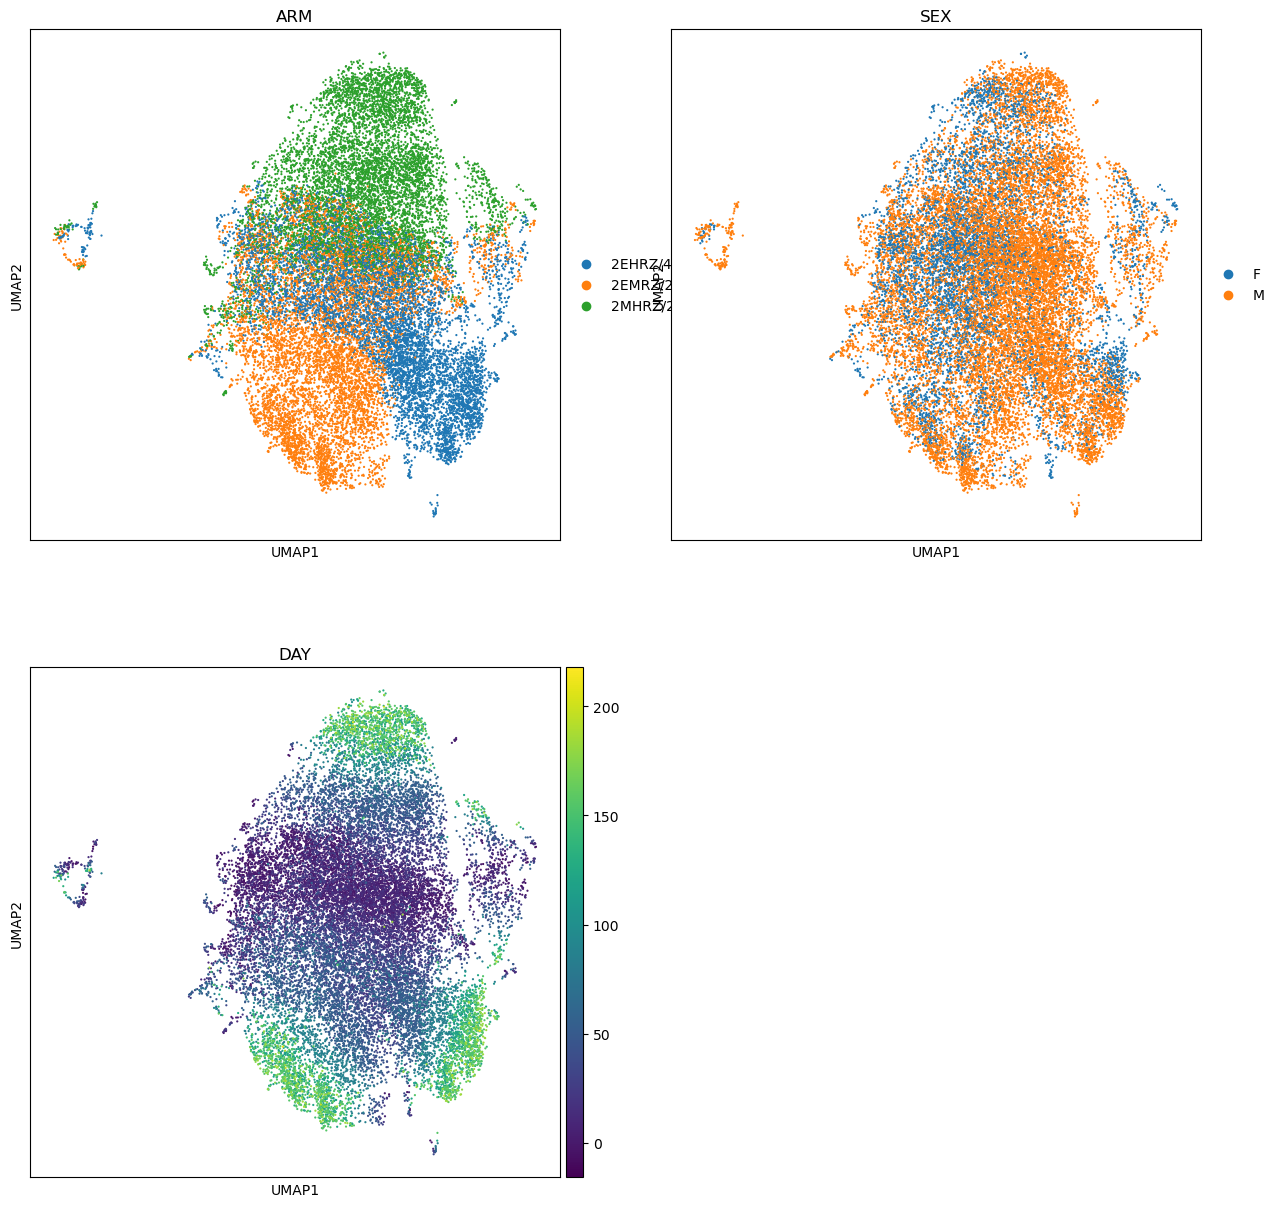

<Figure size 700x700 with 0 Axes>

In [8]:
cdata_norm.obs.loc[cdata_norm.obs['DAY']<-30,'DAY']=0
color_by=['ARM','SEX','DAY']\
          #+ cdata.var_names.tolist()\
          #+ cdata_norm.obs.columns[cdata_norm.obs.columns.str.startswith('out')].tolist() 
#color_by=['STUDYID','DAY']
#color_by=['STUDYID','ARM','DAY']+ cdata_norm.var_names[cdata_norm.var_names.str.startswith('dr_reg')].tolist() 
#fig,ax=plt.subplots(1,1,figsize=(8,6))
s=10

#fig,ax=plt.subplots(len(color_by),1,figsize=(12,8))
with plt.rc_context({"figure.figsize": (7, 7),"figure.dpi": (100)}):
    #ep.pl.pca(cdata_norm,color=color_by,size=s)
    ep.pl.umap(cdata_norm,color=color_by,size=s,ncols=2,wspace=0.1)
    plt.tight_layout()

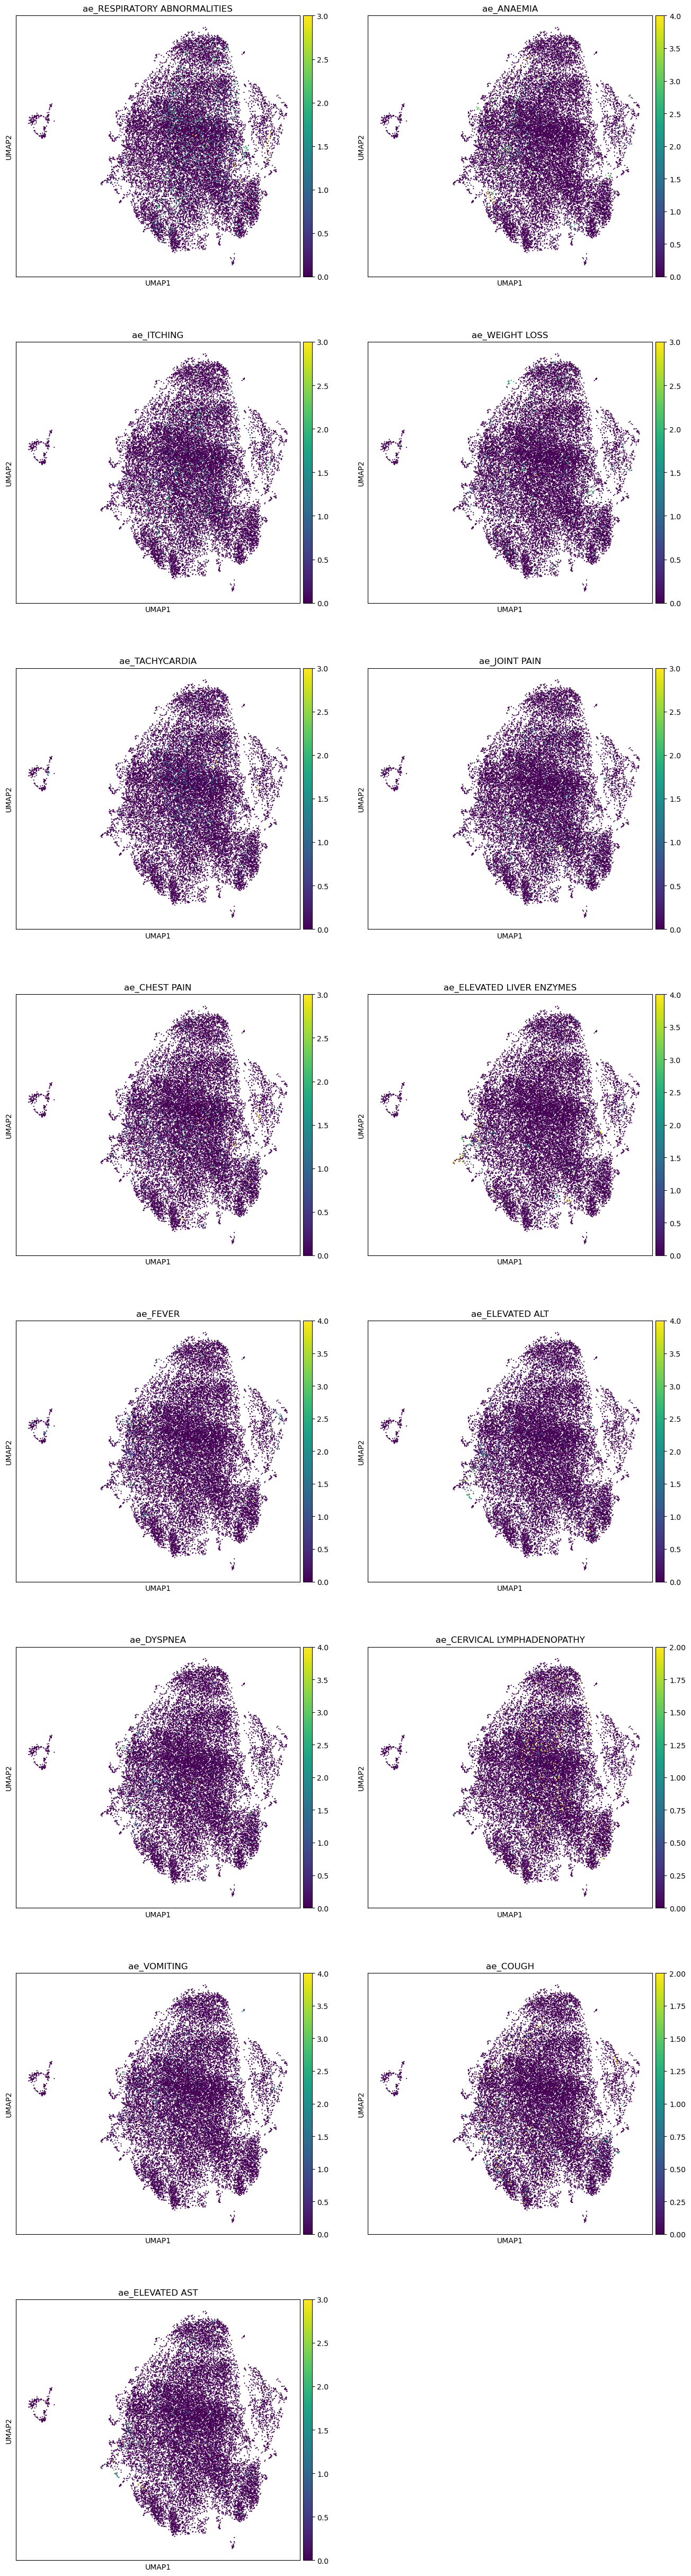

<Figure size 700x700 with 0 Axes>

In [9]:
# Define the binary column names
most_freq_ae_terms=cdata_norm.obs.loc[:,cdata_norm.obs.columns.str.startswith('ae')].sum().sort_values(ascending=False).index.tolist()[0:15]


# Create a composite mask based on the binary column values in the .obs object
composite_mask = np.all([cdata_norm.obs[column] == 1 for column in most_freq_ae_terms], axis=0)

s=10
color_by=most_freq_ae_terms
#fig,ax=plt.subplots(len(color_by),1,figsize=(12,8))
with plt.rc_context({"figure.figsize": (7, 7),"figure.dpi": (100)}):
    #ep.pl.pca(cdata_norm,color=color_by,size=s)
    ep.pl.umap(cdata_norm,color=color_by,size=s,ncols=2)
    plt.tight_layout()
    
# Plot the UMAP visualization with masked data points
#sc.pl.umap(adata, color='binary_column1', mask=composite_mask, legend_loc='on data')

In [10]:
plt.matshow(dataframe.corr())
plt.show()

╭─────────────────────────────────────── Traceback (most recent call last) ───────────────────────────────────────╮
│ in <module>:1                                                                                                   │
│                                                                                                                 │
│ ❱ 1 plt.matshow(dataframe.corr())                                                                               │
│   2 plt.show()                                                                                                  │
│   3                                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'dataframe' is not defined